Tweet:
"I HATE you!!!"

↓ Cleaning
"i hate you"

↓ Tokenization
["i","hate","you"]

↓ Encoding
[8,9,5]

↓ Padding
[8,9,5,0,0,...]

↓ Embedding
Vectors

↓ RNN
Understands meaning

↓ Output
0.95 → Hate Speech

In [1]:
import pandas as pd
import numpy as np

In [2]:
import pandas as pd
import numpy as np
import re
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

In [3]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [4]:
df = pd.read_csv('imbalanced_data.csv')
df

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation
...,...,...,...
31957,31958,0,ate @user isz that youuu?ðððððð...
31958,31959,0,to see nina turner on the airwaves trying to...
31959,31960,0,listening to sad songs on a monday morning otw...
31960,31961,1,"@user #sikh #temple vandalised in in #calgary,..."


In [5]:
df.sample(10)

,id,label,tweet
21810,21811,0,"if you want more #success, something needs to ..."
23083,23084,0,19 #dogs so happy they'll make you too |
29508,29509,0,@user @user @user @user just watched on record...
29995,29996,0,today's the day! to learn &amp; share at the...
17143,17144,0,aunty mi is this home video abi real life
28580,28581,0,#lapride &amp; #bihdayweekend #vibes in the #h...
25820,25821,0,in my #matcha #oreo place. . . #mitsukoshi ...
2506,2507,0,watching girl meets world #tired #loving #be...
8987,8988,0,because everyone temporary... ó¾®ð¾ó¾­»
19941,19942,0,aww yeah it's all good bing bong bing bong


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [7]:
df.isnull().sum()

id       0
label    0
tweet    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
import seaborn as sns

In [10]:
df['label'].value_counts()

label
0    29720
1     2242
Name: count, dtype: int64

<Axes: xlabel='label', ylabel='count'>

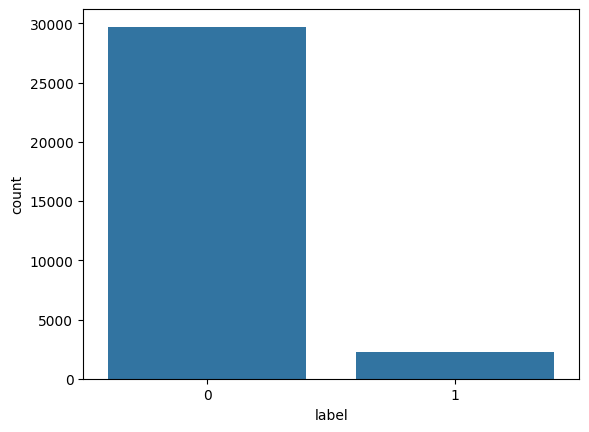

In [11]:
sns.countplot(x='label',data=df)

## Text cleaning 

In [12]:
df

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation
...,...,...,...
31957,31958,0,ate @user isz that youuu?ðððððð...
31958,31959,0,to see nina turner on the airwaves trying to...
31959,31960,0,listening to sad songs on a monday morning otw...
31960,31961,1,"@user #sikh #temple vandalised in in #calgary,..."


In [13]:
for i in df['tweet']:
    print(i)

 @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
@user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked
  bihday your majesty
#model   i love u take with u all the time in urð±!!! ððððð¦ð¦ð¦  
 factsguide: society now    #motivation
[2/2] huge fan fare and big talking before they leave. chaos and pay disputes when they get there. #allshowandnogo  
 @user camping tomorrow @user @user @user @user @user @user @user dannyâ¦
the next school year is the year for exams.ð¯ can't think about that ð­ #school #exams   #hate #imagine #actorslife #revolutionschool #girl
we won!!! love the land!!! #allin #cavs #champions #cleveland #clevelandcavaliers  â¦ 
 @user @user welcome here !  i'm   it's so #gr8 ! 
 â #ireland consumer price index (mom) climbed from previous 0.2% to 0.5% in may   #blog #silver #gold #forex
we are so selfish. #orlando #standwith

In [14]:
import re

In [15]:
def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'@\w+', '', text)  # remove @mentions
    text = re.sub(r'http\S+|www\S+', '', text)  # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)  # remove special chars & numbers
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text


In [16]:
df['clean_tweet'] = df['tweet'].apply(clean_text)

In [17]:
df[['tweet', 'clean_tweet']].sample(10)

,tweet,clean_tweet
3155,nothing can harm you as much as your own thoug...,nothing can harm you as much as your own thoug...
23329,it's cute that you think #hillaryclinton isn't...,its cute that you think hillaryclinton isnt po...
20724,i've finally decided when i go to university n...,ive finally decided when i go to university ne...
26165,always to share good things!,always to share good things
9275,point of views. #cielo #sky #buildings #edific...,point of views cielo sky buildings edificios s...
5151,"keep in mind @user is totally not , but all wh...",keep in mind is totally not but all whites are...
27142,happy end...ðð #manga #anime #skrin end,happy end manga anime skrin end
9656,i can't get angry and hence i suffer.. as i al...,i cant get angry and hence i suffer as i allow...
17844,@user #allahsoil neoliberalism prioritized mon...,allahsoil neoliberalism prioritized money and ...
18572,get down to some @user this wednesday. they hi...,get down to some this wednesday they hit mains...


In [18]:
df

,id,label,tweet,clean_tweet
0,1,0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so selfi...
1,2,0,@user @user thanks for #lyft credit i can't us...,thanks for lyft credit i cant use cause they d...
2,3,0,bihday your majesty,bihday your majesty
3,4,0,#model i love u take with u all the time in ...,model i love u take with u all the time in ur
4,5,0,factsguide: society now #motivation,factsguide society now motivation
...,...,...,...,...
31957,31958,0,ate @user isz that youuu?ðððððð...,ate isz that youuu
31958,31959,0,to see nina turner on the airwaves trying to...,to see nina turner on the airwaves trying to w...
31959,31960,0,listening to sad songs on a monday morning otw...,listening to sad songs on a monday morning otw...
31960,31961,1,"@user #sikh #temple vandalised in in #calgary,...",sikh temple vandalised in in calgary wso conde...


## 3 Tokenization

In [19]:
df

,id,label,tweet,clean_tweet
0,1,0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so selfi...
1,2,0,@user @user thanks for #lyft credit i can't us...,thanks for lyft credit i cant use cause they d...
2,3,0,bihday your majesty,bihday your majesty
3,4,0,#model i love u take with u all the time in ...,model i love u take with u all the time in ur
4,5,0,factsguide: society now #motivation,factsguide society now motivation
...,...,...,...,...
31957,31958,0,ate @user isz that youuu?ðððððð...,ate isz that youuu
31958,31959,0,to see nina turner on the airwaves trying to...,to see nina turner on the airwaves trying to w...
31959,31960,0,listening to sad songs on a monday morning otw...,listening to sad songs on a monday morning otw...
31960,31961,1,"@user #sikh #temple vandalised in in #calgary,...",sikh temple vandalised in in calgary wso conde...


In [20]:
tokens = df['clean_tweet'].apply(lambda x: x.split())


In [21]:
tokens

0        [when, a, father, is, dysfunctional, and, is, ...
1        [thanks, for, lyft, credit, i, cant, use, caus...
2                                  [bihday, your, majesty]
3        [model, i, love, u, take, with, u, all, the, t...
4                   [factsguide, society, now, motivation]
                               ...                        
31957                              [ate, isz, that, youuu]
31958    [to, see, nina, turner, on, the, airwaves, try...
31959    [listening, to, sad, songs, on, a, monday, mor...
31960    [sikh, temple, vandalised, in, in, calgary, ws...
31961                       [thank, you, for, you, follow]
Name: clean_tweet, Length: 31962, dtype: object

## 4: Vocabulary Creation

In [22]:
MAX_VOCAB = 5000

# Flatten all words
all_words = [word for sentence in tokens for word in sentence]

# Count frequency
freq = Counter(all_words)

# Take top words
vocab = {word: idx+2 for idx, (word, _) in enumerate(freq.most_common(MAX_VOCAB-2))}

# Add special tokens
vocab['<PAD>'] = 0
vocab['<OOV>'] = 1

print(list(vocab.items())[:10])

[('the', 2), ('to', 3), ('a', 4), ('i', 5), ('you', 6), ('and', 7), ('in', 8), ('for', 9), ('is', 10), ('of', 11)]


In [23]:
vocab

{'the': 2,
 'to': 3,
 'a': 4,
 'i': 5,
 'you': 6,
 'and': 7,
 'in': 8,
 'for': 9,
 'is': 10,
 'of': 11,
 'my': 12,
 'love': 13,
 'this': 14,
 'on': 15,
 'with': 16,
 'it': 17,
 'be': 18,
 'day': 19,
 'so': 20,
 'all': 21,
 'are': 22,
 'that': 23,
 'me': 24,
 'your': 25,
 'happy': 26,
 'at': 27,
 'have': 28,
 'amp': 29,
 'just': 30,
 'its': 31,
 'we': 32,
 'will': 33,
 'when': 34,
 'not': 35,
 'am': 36,
 'do': 37,
 'im': 38,
 'u': 39,
 'life': 40,
 'time': 41,
 'but': 42,
 'what': 43,
 'from': 44,
 'like': 45,
 'up': 46,
 'today': 47,
 'now': 48,
 'new': 49,
 'as': 50,
 'out': 51,
 'positive': 52,
 'thankful': 53,
 'get': 54,
 'was': 55,
 'about': 56,
 'people': 57,
 'our': 58,
 'bihday': 59,
 'how': 60,
 'good': 61,
 'by': 62,
 'cant': 63,
 'no': 64,
 'one': 65,
 'see': 66,
 'can': 67,
 'dont': 68,
 'fathers': 69,
 'more': 70,
 'they': 71,
 'smile': 72,
 'if': 73,
 'go': 74,
 'want': 75,
 'take': 76,
 'work': 77,
 'who': 78,
 'healthy': 79,
 'fun': 80,
 'weekend': 81,
 'an': 82,
 'has'

## 5: Convert Text → Sequences

In [24]:
def text_to_seq(sentence):
    return [vocab.get(word, vocab['<OOV>']) for word in sentence]

In [25]:
sequences = tokens.apply(text_to_seq)

In [26]:
sequences

0        [34, 4, 254, 10, 1, 7, 10, 20, 3199, 100, 1, 9...
1        [170, 9, 1, 2342, 5, 63, 430, 627, 71, 68, 147...
2                                           [59, 25, 3200]
3          [140, 5, 13, 39, 76, 16, 39, 21, 2, 41, 8, 112]
4                                    [2770, 1574, 48, 285]
                               ...                        
31957                                     [2340, 1, 23, 1]
31958    [3, 66, 1, 1, 15, 2, 1, 491, 3, 3793, 3558, 8,...
31959    [1052, 3, 123, 1269, 15, 4, 294, 110, 1, 3, 77...
31960      [1510, 1283, 1553, 8, 8, 1373, 1554, 1555, 660]
31961                                  [167, 6, 9, 6, 157]
Name: clean_tweet, Length: 31962, dtype: object

## 6: Padding

In [27]:
MAX_LEN = 25

X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = df['label'].values

In [28]:
X

array([[  34,    4,  254, ...,    0,    0,    0],
       [ 170,    9,    1, ...,    0,    0,    0],
       [  59,   25, 3200, ...,    0,    0,    0],
       ...,
       [1052,    3,  123, ...,    0,    0,    0],
       [1510, 1283, 1553, ...,    0,    0,    0],
       [ 167,    6,    9, ...,    0,    0,    0]],
      shape=(31962, 25), dtype=int32)

In [29]:
X[0]

array([  34,    4,  254,   10,    1,    7,   10,   20, 3199,  100,    1,
         93,  249,  250,   93,    1,  462,    0,    0,    0,    0,    0,
          0,    0,    0], dtype=int32)

In [30]:
y

array([0, 0, 0, ..., 0, 1, 0], shape=(31962,))

## 7: Train-Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,stratify=y,random_state=42)

## 8: Build RNN Model

In [32]:
model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=64, input_length=MAX_LEN),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

c:\Users\sidda\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [33]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 9 Train Model

In [34]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9306 - loss: 0.2409 - val_accuracy: 0.9374 - val_loss: 0.2085
Epoch 2/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9436 - loss: 0.1760 - val_accuracy: 0.9261 - val_loss: 0.2107
Epoch 3/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9490 - loss: 0.1576 - val_accuracy: 0.9421 - val_loss: 0.1970
Epoch 4/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9573 - loss: 0.1379 - val_accuracy: 0.9304 - val_loss: 0.2346
Epoch 5/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9660 - loss: 0.1108 - val_accuracy: 0.9370 - val_loss: 0.2187
Epoch 6/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9720 - loss: 0.0921 - val_accuracy: 0.9355 - val_loss: 0.2351
Epoch 7/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9741 - loss: 0.0852 - val_accuracy: 0.9339 - val_loss: 0.2550
Epoch 8/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9752 - loss: 0.0783 - val_accuracy: 0.

## 10 Evalve model

In [35]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.9325825121226341

Confusion Matrix:
 [[5759  186]
 [ 245  203]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96      5945
           1       0.52      0.45      0.49       448

    accuracy                           0.93      6393
   macro avg       0.74      0.71      0.72      6393
weighted avg       0.93      0.93      0.93      6393



# save model

In [36]:
import pickle

# Save model
model.save("rnn_model.h5")

# Save vocab
with open("vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)